## Preprocessing

In [1]:
import pandas as pd
import numpy as np

In [2]:
cols = ['Unnamed: 0',
 'Flow ID',
 'Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Fwd Byts/b Avg',
 'Fwd Pkts/b Avg',
 'Fwd Blk Rate Avg',
 'Bwd Byts/b Avg',
 'Bwd Pkts/b Avg',
 'Bwd Blk Rate Avg',
 'Subflow Fwd Pkts',
 'Subflow Fwd Byts',
 'Subflow Bwd Pkts',
 'Subflow Bwd Byts',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Act Data Pkts',
 'Fwd Seg Size Min',
 'Active Mean',
 'Active Std',
 'Active Max',
 'Active Min',
 'Idle Mean',
 'Idle Std',
 'Idle Max',
 'Idle Min',
 'Label']

In [3]:
chunks = []
chunk_size = 100000

for chunk_idx, chunk in enumerate(pd.read_csv("/kaggle/input/ddos-datasets/ddos_balanced/final_dataset.csv", chunksize=chunk_size)):
    chunk_ = chunk.sample(frac=0.05, random_state=42)
    chunks.append(chunk_)
    if chunk_idx%10 == 0:
        print(f"Chunk {chunk_idx} done")
print("Complete")

Chunk 0 done
Chunk 10 done
Chunk 20 done
Chunk 30 done
Chunk 40 done
Chunk 50 done
Chunk 60 done
Chunk 70 done
Chunk 80 done
Chunk 90 done
Chunk 100 done
Chunk 110 done
Chunk 120 done
Complete


In [4]:
df = pd.concat(chunks, ignore_index=True)
del chunks

In [5]:
df["Label"].value_counts()

Label
ddos      323654
Benign    316077
Name: count, dtype: int64

In [6]:
df.to_parquet('/kaggle/working/sample_data.parquet', index=False)

In [7]:
# df = pd.read_parquet("/kaggle/working/sample_data.parquet")

In [8]:
df.head()

,Unnamed: 0,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22165,172.31.69.25-18.219.211.138-80-34408-6,18.219.211.138,34408,172.31.69.25,80,6,15/02/2018 07:24:59 PM,5032233,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos
1,26628,172.31.69.25-18.219.211.138-80-40676-6,18.219.211.138,40676,172.31.69.25,80,6,15/02/2018 07:26:24 PM,10993127,3,...,0,783.0,0.0,783.0,783.0,5990709.0,0.0,5990709.0,5990709.0,ddos
2,76682,192.168.2.109-203.73.24.75-4020-80-6,192.168.2.109,4020,203.73.24.75,80,6,12/06/2010 03:12:15 PM,479425,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos
3,23143,172.31.69.25-18.219.211.138-80-36102-6,18.219.211.138,36102,172.31.69.25,80,6,15/02/2018 07:08:53 PM,9042123,1,...,0,0.0,0.0,0.0,0.0,9042123.0,0.0,9042123.0,9042123.0,ddos
4,39435,172.31.69.25-18.219.211.138-80-44284-6,18.219.211.138,44284,172.31.69.25,80,6,15/02/2018 07:19:56 PM,1907579,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos


In [9]:
df.columns.tolist()

['Unnamed: 0',
 'Flow ID',
 'Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pk

In [10]:
df.drop(columns=["Unnamed: 0", "Flow ID"], inplace=True)

In [11]:
df.head()

,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,18.219.211.138,34408,172.31.69.25,80,6,15/02/2018 07:24:59 PM,5032233,3,5,603.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos
1,18.219.211.138,40676,172.31.69.25,80,6,15/02/2018 07:26:24 PM,10993127,3,5,408.0,...,0,783.0,0.0,783.0,783.0,5990709.0,0.0,5990709.0,5990709.0,ddos
2,192.168.2.109,4020,203.73.24.75,80,6,12/06/2010 03:12:15 PM,479425,3,7,142.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos
3,18.219.211.138,36102,172.31.69.25,80,6,15/02/2018 07:08:53 PM,9042123,1,1,0.0,...,0,0.0,0.0,0.0,0.0,9042123.0,0.0,9042123.0,9042123.0,ddos
4,18.219.211.138,44284,172.31.69.25,80,6,15/02/2018 07:19:56 PM,1907579,1,1,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos


In [12]:
# Convert IP strings into octets efficiently using NumPy
def ip_to_octets(ip_series, prefix):
    octets = np.stack(ip_series.str.split('.').apply(lambda x: list(map(int, x))))
    return pd.DataFrame(octets, columns=[f"{prefix} Octet{i+1}" for i in range(4)])

In [13]:
# Apply the optimized function
src_octets = ip_to_octets(df["Src IP"], "Src IP")
dst_octets = ip_to_octets(df["Dst IP"], "Dst IP")

# Concatenate with original DataFrame
df = pd.concat([df, src_octets, dst_octets], axis=1).drop(columns=["Src IP", "Dst IP"])

# Done
print("IP segmentation Done")

# Delete unused vars
del src_octets
del dst_octets

IP segmentation Done


In [14]:
columns_with_nan = df.columns[df.isnull().any()]

for col in columns_with_nan:
    print(f"Column '{col}' has {df[col].isnull().sum()} NaN values")

Column 'Flow Byts/s' has 1454 NaN values


In [15]:
# columns_with_inf = df1.columns[np.isinf(train_X).any()]

# for col in columns_with_inf:
#     print(f"Column '{col}' has {df1[col].isnull().sum()} INF values")

In [16]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [17]:
df = pd.DataFrame(df.dropna(), columns=df.columns)

In [18]:
y = df["Label"]
X = df.drop(columns=["Label"])

In [19]:
print(y.isnull().any().sum())
print(X.isnull().any().sum())

0
0


In [20]:
y.nunique()

2

In [21]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

In [22]:
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
non_numerical_cols = X.select_dtypes(exclude=np.number).columns.tolist()
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

print(train_X.isnull().any(axis=1).sum())
print(test_X.isnull().any(axis=1).sum())
print(train_y.isnull().sum())
print(test_y.isnull().sum())

0
0
0
0


In [23]:
non_numerical_cols

['Timestamp']

In [24]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")

train_X[numerical_cols] = pd.DataFrame(imputer.fit_transform(train_X[numerical_cols]), columns=numerical_cols, index=train_X.index)  # DO NOT remove the index=xxx attribute, else NaN happens
test_X[numerical_cols] = pd.DataFrame(imputer.transform(test_X[numerical_cols]), columns=numerical_cols, index=test_X.index)

print(train_X.isnull().any(axis=1).sum())
print(test_X.isnull().any(axis=1).sum())

print("Imputing complete")

0
0
Imputing complete


In [25]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_X[numerical_cols])
train_X[numerical_cols] = pd.DataFrame(train_scaled, columns=numerical_cols, index=train_X.index) # index=train_X.index remove
test_X[numerical_cols] = pd.DataFrame(scaler.transform(test_X[numerical_cols]), columns=numerical_cols, index=test_X.index) # index=test_X.index remove

print(train_X.isnull().any(axis=1).sum())
print(test_X.isnull().any(axis=1).sum())

print("Scaling complete")

0
0
Scaling complete


In [26]:
train_X.head()
train_X.shape

(509913, 88)

In [27]:
train_X.head()

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Max,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4
75729,0.001221,0.905698,0.352941,21/02/2018 11:56:52 PM,0.000010,0.000013,0.000139,0.000094,0.000011,0.040026,...,0.000000,0.000000,0.770270,0.121569,0.270588,0.109804,0.066929,0.854902,0.215686,0.494118
380503,0.816739,0.006760,0.352941,20/02/2018 02:31:03,0.751382,0.000039,0.000924,0.000096,0.000099,0.011601,...,0.374807,0.374778,0.770270,0.121569,0.254902,0.172549,0.507874,0.827451,0.149020,0.568627
197468,0.669505,0.001221,0.352941,16/02/2018 11:22:44 PM,0.000015,0.000003,0.000046,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039
201241,0.907332,0.001221,0.352941,16/02/2018 11:23:36 PM,0.000056,0.000003,0.000046,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039
10309,0.864805,0.001221,0.352941,21/02/2018 11:43:51 PM,0.000247,0.000003,0.000046,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.076577,0.854902,0.450980,0.235294,0.673228,0.121569,0.270588,0.109804


In [28]:
train_X.isnull().any(axis=1).sum()

0

In [29]:
train_y = train_y.map({"Benign": 0, "ddos": 1})

In [30]:
test_y = test_y.map({"Benign": 0, "ddos": 1})

In [31]:
print(train_y.isnull().sum())
print(test_y.isnull().sum())

0
0


## Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression

# Train
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(train_X[numerical_cols], train_y.reset_index(drop=True))

# Print
print("Model trained successfully")

Model trained successfully


In [33]:
y_pred = model.predict(test_X[numerical_cols])

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [35]:
train_X[numerical_cols].shape, test_X[numerical_cols].shape

((509913, 87), (127479, 87))

In [36]:
print("Accuracy:", accuracy_score(test_y.reset_index(drop=True), y_pred))
print("\nClassification Report:\n", classification_report(test_y, y_pred))


Accuracy: 0.991724127111132

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     62679
           1       0.99      0.99      0.99     64800

    accuracy                           0.99    127479
   macro avg       0.99      0.99      0.99    127479
weighted avg       0.99      0.99      0.99    127479



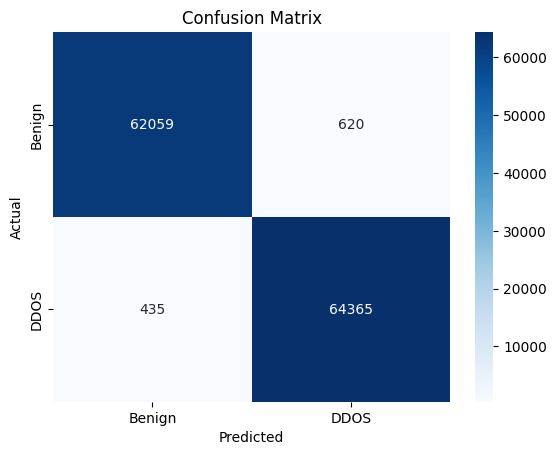

In [37]:
conf_matrix = confusion_matrix(test_y.reset_index(drop=True), y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Benign', 'DDOS'], yticklabels=['Benign', 'DDOS'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

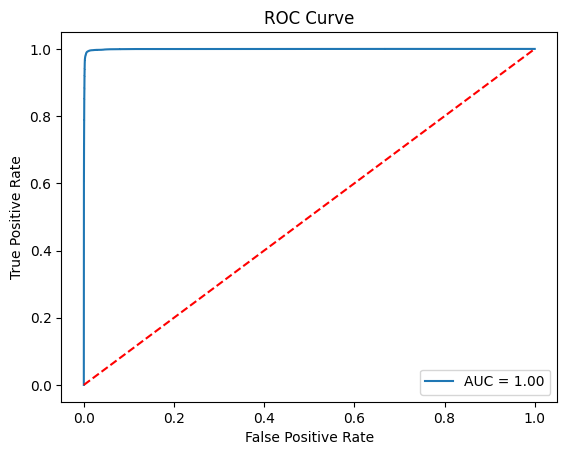

In [38]:
y_pred_proba = model.predict_proba(test_X[numerical_cols])[:,1]
fpr, tpr, _ = roc_curve(test_y.reset_index(drop=True), y_pred_proba)
auc = roc_auc_score(test_y.reset_index(drop=True), y_pred_proba)
plt.plot(fpr, tpr, label="AUC = {:.2f}".format(auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [39]:
import joblib
joblib.dump(model, '/kaggle/working/log_reg_model.pkl')

['/kaggle/working/log_reg_model.pkl']

## Autoencoder

In [40]:
train_X.head()

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Max,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4
75729,0.001221,0.905698,0.352941,21/02/2018 11:56:52 PM,0.000010,0.000013,0.000139,0.000094,0.000011,0.040026,...,0.000000,0.000000,0.770270,0.121569,0.270588,0.109804,0.066929,0.854902,0.215686,0.494118
380503,0.816739,0.006760,0.352941,20/02/2018 02:31:03,0.751382,0.000039,0.000924,0.000096,0.000099,0.011601,...,0.374807,0.374778,0.770270,0.121569,0.254902,0.172549,0.507874,0.827451,0.149020,0.568627
197468,0.669505,0.001221,0.352941,16/02/2018 11:22:44 PM,0.000015,0.000003,0.000046,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039
201241,0.907332,0.001221,0.352941,16/02/2018 11:23:36 PM,0.000056,0.000003,0.000046,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039
10309,0.864805,0.001221,0.352941,21/02/2018 11:43:51 PM,0.000247,0.000003,0.000046,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.076577,0.854902,0.450980,0.235294,0.673228,0.121569,0.270588,0.109804


In [41]:
train_y.reset_index(drop=True).head()
pd.DataFrame(train_y).head()

,Label
75729,1
380503,0
197468,1
201241,1
10309,1


In [42]:
# train_X_benign = train_X[pd.DataFrame(train_y).reset_index(drop=True)["Label"]==0].reset_index(drop=True)  # TODO: Why this doesn't work??
train_X_benign = train_X[pd.DataFrame(train_y)["Label"]==0].reset_index(drop=True)[numerical_cols]
train_X_benign.isna().any(axis=1).sum()

0

In [43]:
train_X_benign.head()

,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Idle Max,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4
0,0.816739,0.006760,0.352941,0.751382,0.000039,0.000924,0.000096,0.000099,0.011601,0.000000,...,0.374807,0.374778,0.77027,0.121569,0.254902,0.172549,0.507874,0.827451,0.149020,0.568627
1,0.893370,0.000809,1.000000,0.000007,0.000003,0.000046,0.000005,0.000002,0.001926,0.030571,...,0.000000,0.000000,0.77027,0.121569,0.250980,0.262745,0.673228,0.121569,0.000000,0.007843
2,0.842466,0.006760,0.352941,0.002912,0.000029,0.000323,0.000056,0.000121,0.008647,0.000000,...,0.000000,0.000000,0.77027,0.121569,0.270588,0.066667,0.200787,0.329412,0.227451,0.882353
3,0.947295,0.000809,1.000000,0.000503,0.000000,0.000092,0.000000,0.000007,0.000000,0.000000,...,0.000000,0.000000,0.86036,0.658824,0.039216,0.011765,0.751969,0.658824,0.039216,0.003922
4,0.773831,0.000809,1.000000,0.000992,0.000006,0.000092,0.000011,0.000010,0.002312,0.036685,...,0.000000,0.000000,0.77027,0.121569,0.258824,0.400000,0.673228,0.121569,0.000000,0.007843


In [44]:
import torch
import torch.nn as nn
import torch.optim as optim

In [45]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim): # x -> x' -> x'' 
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.SELU(),
            nn.Linear(64, 32),
            nn.SELU(),
            nn.Linear(32, 8),
            nn.SELU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(8, 32),
            nn.SELU(),
            nn.Linear(32, 64),
            nn.SELU(),
            nn.Linear(64, input_dim),
            nn.SELU()
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [46]:
input_dim = train_X_benign.shape[1]
model = Autoencoder(input_dim)
criterion = nn.L1Loss()
optimizer = optim.RMSprop(model.parameters(), lr=0.0001)

In [47]:
# train_X_backup = train_X.copy()
# test_X_backup = test_X.copy()
# train_y_backup = train_y.copy()
# test_y_backup = test_y.copy()
# train_X_benign_backup = train_X_benign.copy()

# train_X = train_X_backup.copy()
# test_X = test_X_backup.copy()
# train_y = train_y_backup.copy()
# test_y = test_y_backup.copy()
# train_X_benign = train_X_benign_backup.copy()

In [48]:
if not isinstance(train_X, torch.Tensor):
    train_X = torch.FloatTensor(train_X[numerical_cols].values)
if not isinstance(train_y, torch.Tensor):
    train_y = torch.LongTensor(train_y.values)
if not isinstance(test_X, torch.Tensor):
    test_X = torch.FloatTensor(test_X[numerical_cols].values)
if not isinstance(test_y, torch.Tensor):
    test_y = torch.LongTensor(test_y.values)
if not isinstance(train_X_benign, torch.Tensor):
    train_X_benign = torch.FloatTensor(train_X_benign.values)

In [49]:
print(type(train_X))
print(type(train_y))
print(type(test_X))
print(type(test_y))
print(type(train_X_benign))

<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [50]:
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(TensorDataset(train_X_benign), batch_size=32, shuffle=True)
epochs = 30

In [51]:
epoch_losses = []
reconstruction_losses_last_epoch = [] 
for epoch in range(epochs):
    model.train()   # set the model to training mode 
    total_loss = 0
    # using mini batch gradient descent
    for batch in train_loader:
        inputs = batch[0]
        optimizer.zero_grad()    # reset the gradients for each batch
        outputs = model(inputs)  # forward pass
        loss = criterion(outputs, inputs)    
        loss.backward()     # backward pass
        optimizer.step()    # update the weights
        total_loss += loss.item()

        # Track individual sample reconstruction losses only in the last epoch
        if epoch == epochs - 1:  # Collect only for the last epoch
            reconstruction_losses_last_epoch.extend(loss.item() for _ in range(len(inputs)))
            
    epoch_loss = total_loss/len(train_loader)
    epoch_losses.append(epoch_loss)
    print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}') 
print("Autoencoder training complete")

Epoch 1/30, Loss: 0.0431
Epoch 2/30, Loss: 0.0337
Epoch 3/30, Loss: 0.0310
Epoch 4/30, Loss: 0.0297
Epoch 5/30, Loss: 0.0271
Epoch 6/30, Loss: 0.0253
Epoch 7/30, Loss: 0.0239
Epoch 8/30, Loss: 0.0232
Epoch 9/30, Loss: 0.0227
Epoch 10/30, Loss: 0.0214
Epoch 11/30, Loss: 0.0205
Epoch 12/30, Loss: 0.0200
Epoch 13/30, Loss: 0.0196
Epoch 14/30, Loss: 0.0191
Epoch 15/30, Loss: 0.0188
Epoch 16/30, Loss: 0.0185
Epoch 17/30, Loss: 0.0182
Epoch 18/30, Loss: 0.0180
Epoch 19/30, Loss: 0.0177
Epoch 20/30, Loss: 0.0175
Epoch 21/30, Loss: 0.0172
Epoch 22/30, Loss: 0.0170
Epoch 23/30, Loss: 0.0168
Epoch 24/30, Loss: 0.0166
Epoch 25/30, Loss: 0.0165
Epoch 26/30, Loss: 0.0164
Epoch 27/30, Loss: 0.0163
Epoch 28/30, Loss: 0.0162
Epoch 29/30, Loss: 0.0161
Epoch 30/30, Loss: 0.0160
Autoencoder training complete


In [52]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

reconstruction_losses_last_epoch = np.array(reconstruction_losses_last_epoch)

mean_loss = np.mean(reconstruction_losses_last_epoch)
std_loss = np.std(reconstruction_losses_last_epoch)

threshold = 1 * mean_loss + 2.5 * std_loss # Define threshold to have the highest recall possible. 

print(f"Anomaly Detection Threshold: {threshold}")

Anomaly Detection Threshold: 0.02211500408553449


In [53]:
model.eval()
reconstruction_errors = []
test_labels = test_y.numpy()

with torch.no_grad():
    outputs = model(test_X)
    reconstruction_errors = torch.mean(torch.abs(outputs - test_X), dim=1).numpy()

predicted_labels = (reconstruction_errors > threshold).astype(int)

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [55]:
accuracy = accuracy_score(test_labels, predicted_labels)
precision = precision_score(test_labels, predicted_labels)
recall = recall_score(test_labels, predicted_labels)
f1 = f1_score(test_labels, predicted_labels)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8703
Precision: 0.7967
Recall: 1.0000
F1 Score: 0.8869


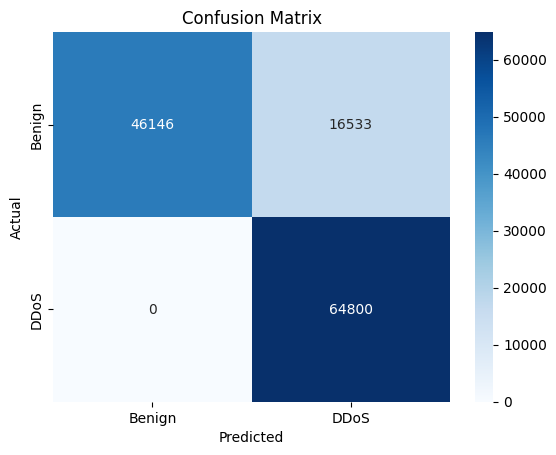

In [56]:
cm = confusion_matrix(test_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'DDoS'], yticklabels=['Benign', 'DDoS'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [57]:
torch.save(model, "/kaggle/working/autoencoder.pt")

## LSTM